<a href="https://colab.research.google.com/github/manojgundumogula55-commits/Digital-Library-Usage-And-Resource-Analytics/blob/main/Digital_Library_Usage_Analytics/04_Data_Visualization_Results_and_Interpretation/%20Data_Visualization_Results_Interpretation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Digital Library Usage Analysis
## Data Visualization, Results and Interpretation
### This notebook covers the Data Visualization, Results and Interpretation stages of the project. It uses the cleaned dataset produced in Stage 2.

# 1. Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

In [3]:
# 2. Load the Cleaned Dataset

In [4]:
from google.colab import files

uploaded = files.upload()
file_name = next(iter(uploaded))

df = pd.read_csv(file_name, parse_dates=["access_datetime"])

print("Cleaned dataset loaded successfully.")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Saving library_usage_clean.csv to library_usage_clean.csv
Cleaned dataset loaded successfully.
Rows: 1456
Columns: 19


In [5]:
## 2.1 Setup for Saving Figures

In [6]:
os.makedirs("output/figures", exist_ok=True)

month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday",
             "Friday", "Saturday", "Sunday"]

def save_figure(name):
    plt.tight_layout()
    plt.savefig(f"output/figures/{name}.png", dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved: output/figures/{name}.png")

In [7]:
# 3. Data Visualization
### Each chart answers one question from the analysis stage.

## 3.1 Library Accesses by Month

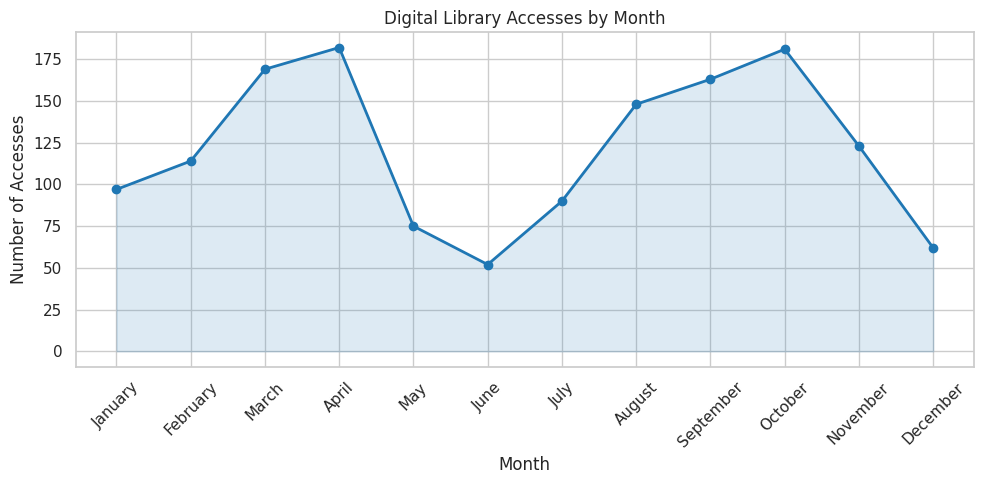

Saved: output/figures/usage_by_month.png


In [8]:
monthly = df["month"].value_counts().reindex(month_order)

plt.figure(figsize=(10, 5))
plt.plot(monthly.index, monthly.values, marker="o", linewidth=2, color="#1f77b4")
plt.fill_between(monthly.index, monthly.values, alpha=0.15, color="#1f77b4")
plt.title("Digital Library Accesses by Month")
plt.xlabel("Month")
plt.ylabel("Number of Accesses")
plt.xticks(rotation=45)

save_figure("usage_by_month")

In [9]:
## 3.2 Top 10 Most Accessed Resources

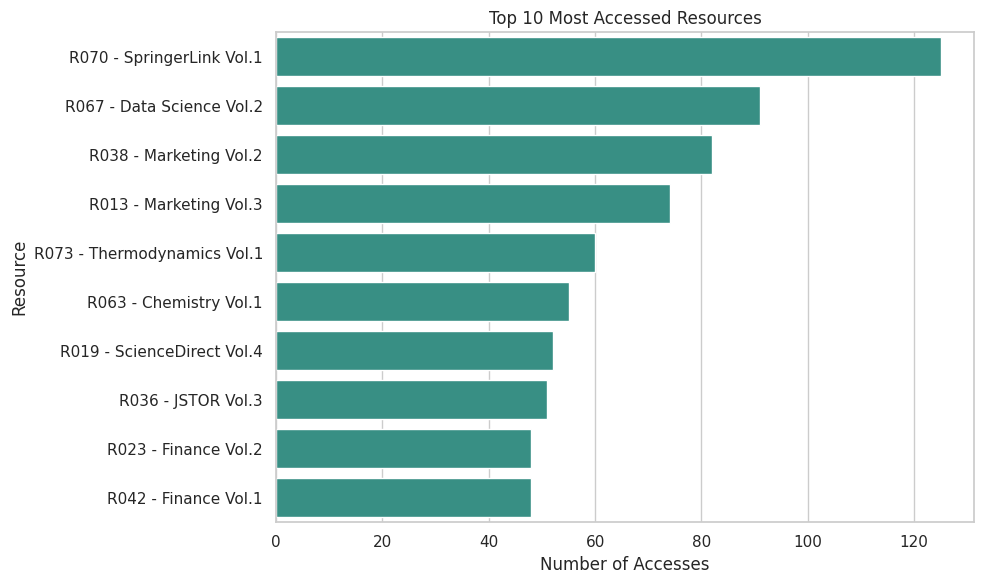

Saved: output/figures/top_10_resources.png


In [10]:
top_resources = (
    df.groupby(["resource_id", "resource_title"]).size()
      .sort_values(ascending=False).head(10)
      .reset_index(name="access_count")
)
top_resources["label"] = top_resources["resource_id"] + " - " + top_resources["resource_title"]

plt.figure(figsize=(10, 6))
sns.barplot(data=top_resources, x="access_count", y="label", color="#2a9d8f")
plt.title("Top 10 Most Accessed Resources")
plt.xlabel("Number of Accesses")
plt.ylabel("Resource")

save_figure("top_10_resources")

In [11]:
## 3.3 Accesses by Department

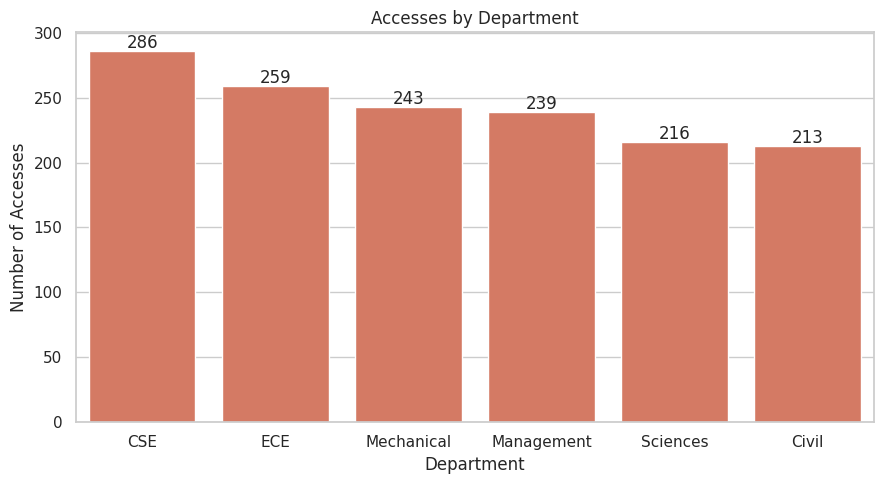

Saved: output/figures/usage_by_department.png


In [12]:
dept_counts = df["department"].value_counts()

plt.figure(figsize=(9, 5))
sns.barplot(x=dept_counts.index, y=dept_counts.values, color="#e76f51")
plt.title("Accesses by Department")
plt.xlabel("Department")
plt.ylabel("Number of Accesses")

for i, value in enumerate(dept_counts.values):
    plt.text(i, value + 2, str(value), ha="center")

save_figure("usage_by_department")

In [13]:
## 3.4 Resource Type Share

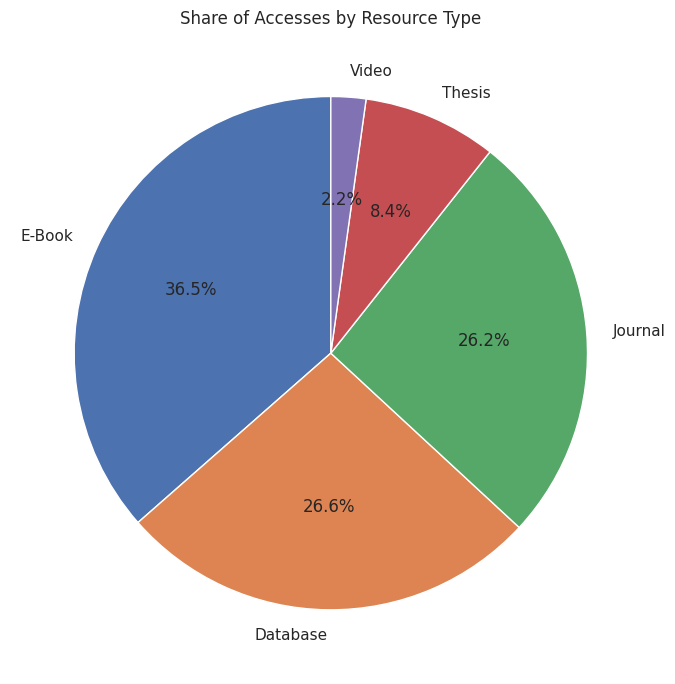

Saved: output/figures/resource_type_share.png


In [14]:
type_counts = df["resource_type"].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(
    type_counts.values,
    labels=type_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white"}
)
plt.title("Share of Accesses by Resource Type")

save_figure("resource_type_share")

In [15]:
## 3.5 Accesses by User Type

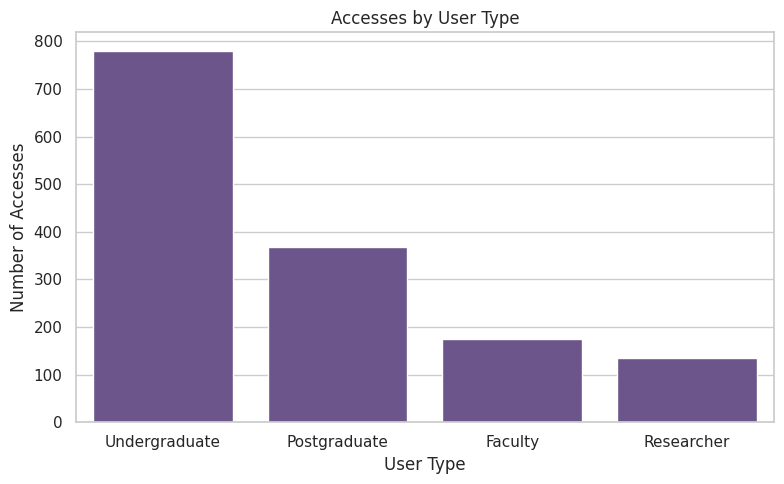

Saved: output/figures/usage_by_user_type.png


In [16]:
user_counts = df["user_type"].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=user_counts.index, y=user_counts.values, color="#6a4c93")
plt.title("Accesses by User Type")
plt.xlabel("User Type")
plt.ylabel("Number of Accesses")

save_figure("usage_by_user_type")

In [17]:
## 3.6 Peak Usage: Weekday vs Hour

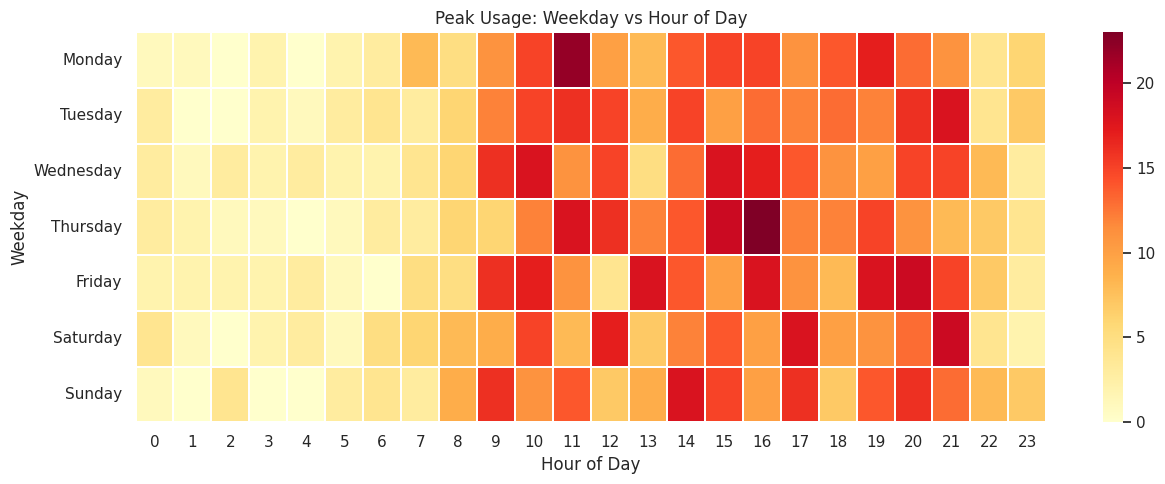

Saved: output/figures/peak_hours_heatmap.png


In [18]:
weekday_hour = df.pivot_table(
    index="weekday",
    columns="hour",
    values="access_id",
    aggfunc="count",
    fill_value=0
).reindex(day_order)

plt.figure(figsize=(13, 5))
sns.heatmap(weekday_hour, cmap="YlOrRd", linewidths=0.3)
plt.title("Peak Usage: Weekday vs Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Weekday")

save_figure("peak_hours_heatmap")

In [19]:
## 3.7 Average Session Time by User Type

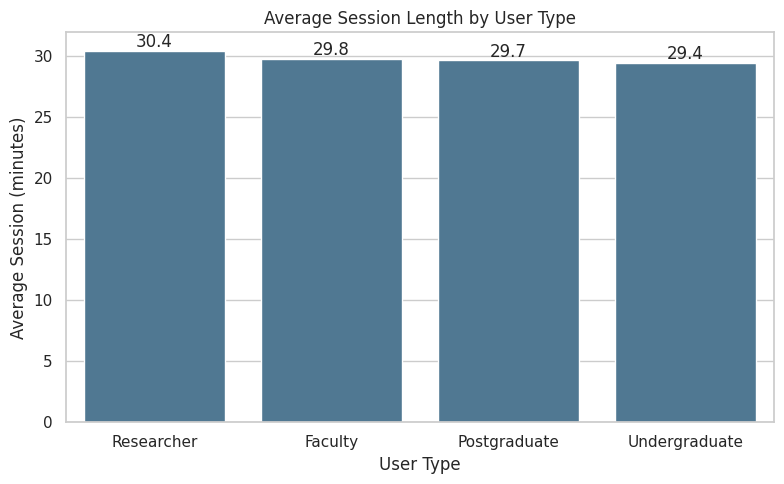

Saved: output/figures/avg_session_by_user_type.png


In [20]:
avg_session = df.groupby("user_type")["session_minutes"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=avg_session.index, y=avg_session.values, color="#457b9d")
plt.title("Average Session Length by User Type")
plt.xlabel("User Type")
plt.ylabel("Average Session (minutes)")

for i, value in enumerate(avg_session.values):
    plt.text(i, value + 0.3, f"{value:.1f}", ha="center")

save_figure("avg_session_by_user_type")

In [21]:
## 3.8 Download Rate by Resource Type

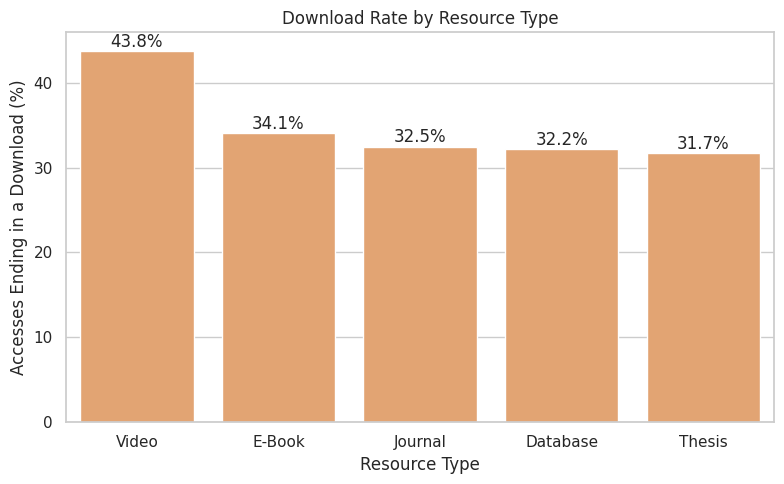

Saved: output/figures/download_rate_by_resource_type.png


In [22]:
download_rate = (df.groupby("resource_type")["downloaded"].mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=download_rate.index, y=download_rate.values, color="#f4a261")
plt.title("Download Rate by Resource Type")
plt.xlabel("Resource Type")
plt.ylabel("Accesses Ending in a Download (%)")

for i, value in enumerate(download_rate.values):
    plt.text(i, value + 0.5, f"{value:.1f}%", ha="center")

save_figure("download_rate_by_resource_type")

In [23]:
## 3.9 Device and Access Mode

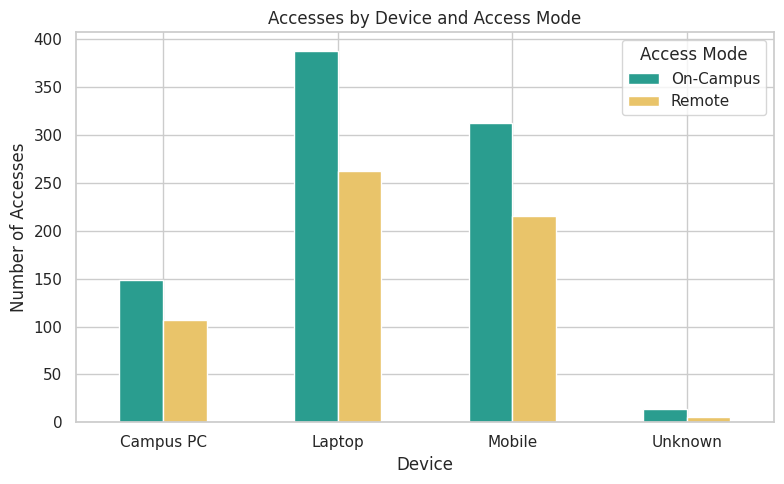

Saved: output/figures/device_and_access_mode.png


In [24]:
device_mode = pd.crosstab(df["device"], df["access_mode"])

device_mode.plot(kind="bar", figsize=(8, 5), color=["#2a9d8f", "#e9c46a"])
plt.title("Accesses by Device and Access Mode")
plt.xlabel("Device")
plt.ylabel("Number of Accesses")
plt.xticks(rotation=0)
plt.legend(title="Access Mode")

save_figure("device_and_access_mode")

In [25]:
## 3.10 Rating Distribution

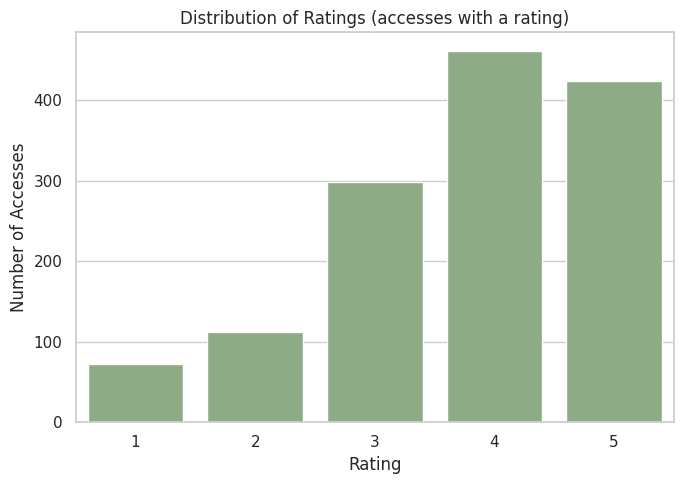

Saved: output/figures/rating_distribution.png


In [26]:
rating_counts = df["rating"].value_counts().sort_index()

plt.figure(figsize=(7, 5))
sns.barplot(x=rating_counts.index.astype(int), y=rating_counts.values, color="#8ab17d")
plt.title("Distribution of Ratings (accesses with a rating)")
plt.xlabel("Rating")
plt.ylabel("Number of Accesses")

save_figure("rating_distribution")

In [27]:
## 3.11 Monthly Usage by Resource Type

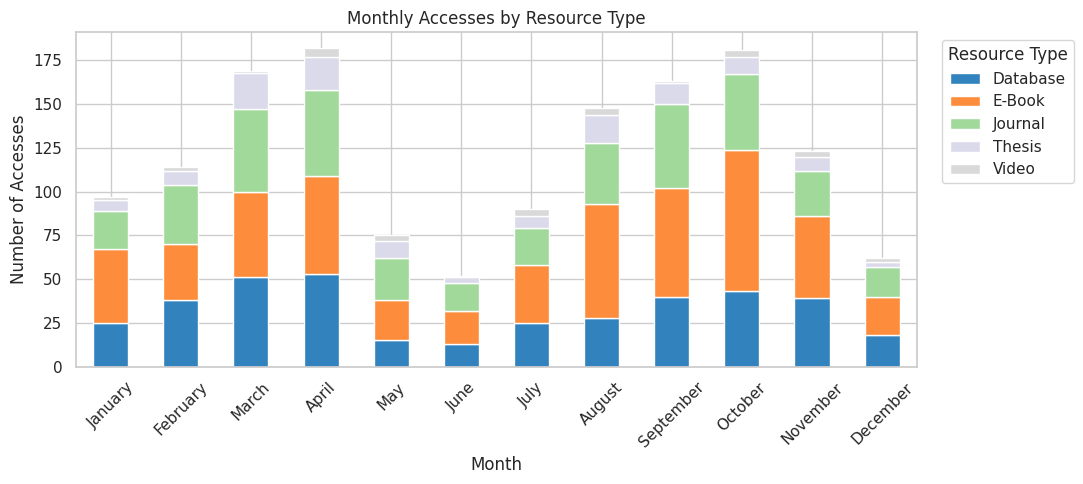

Saved: output/figures/monthly_usage_by_resource_type.png


In [28]:
month_type = pd.crosstab(df["month"], df["resource_type"]).reindex(month_order)

month_type.plot(kind="bar", stacked=True, figsize=(11, 5), colormap="tab20c")
plt.title("Monthly Accesses by Resource Type")
plt.xlabel("Month")
plt.ylabel("Number of Accesses")
plt.xticks(rotation=45)
plt.legend(title="Resource Type", bbox_to_anchor=(1.02, 1), loc="upper left")

save_figure("monthly_usage_by_resource_type")

In [29]:
# 4. Results
### The results below are calculated directly from the cleaned data, so they stay correct if the dataset changes.

## 4.1 Key Numbers

In [30]:
total = len(df)

results = {
    "Total accesses": total,
    "Unique users": df["user_id"].nunique(),
    "Resources accessed": df["resource_id"].nunique(),
    "Average session (minutes)": round(df["session_minutes"].mean(), 1),
    "Download rate (%)": round(df["downloaded"].mean() * 100, 1),
    "Average rating": round(df["rating"].mean(), 2),
    "Remote access (%)": round((df["access_mode"] == "Remote").mean() * 100, 1),
}

display(pd.Series(results, name="value").to_frame())

,value
Total accesses,1456.00
Unique users,619.00
Resources accessed,70.00
Average session (minutes),29.60
Download rate (%),33.20
Average rating,3.77
Remote access (%),40.70


In [31]:
## 4.2 Results Table

In [32]:
resource_counts = df["resource_id"].value_counts()
monthly_counts = df["month"].value_counts()
hour_counts = df["hour"].value_counts()
threshold = resource_counts.quantile(0.10)

top_resource_id = resource_counts.idxmax()
top_title = df.loc[df["resource_id"] == top_resource_id, "resource_title"].iloc[0]

results_table = pd.DataFrame({
    "Question": [
        "Most accessed resource",
        "Most popular resource type",
        "Most active department",
        "Least active department",
        "Most active user type",
        "Peak month",
        "Quietest month",
        "Busiest weekday",
        "Busiest hour",
        "Highest download rate",
        "Longest average session",
        "Underused resources (lowest 10%)"
    ],
    "Result": [
        f"{top_resource_id} - {top_title} ({resource_counts.max()} accesses)",
        df["resource_type"].value_counts().idxmax(),
        df["department"].value_counts().idxmax(),
        df["department"].value_counts().idxmin(),
        df["user_type"].value_counts().idxmax(),
        monthly_counts.idxmax(),
        monthly_counts.idxmin(),
        df["weekday"].value_counts().idxmax(),
        f"{hour_counts.idxmax()}:00",
        f"{download_rate.idxmax()} ({download_rate.max():.1f}%)",
        f"{avg_session.idxmax()} ({avg_session.max():.1f} min)",
        int((resource_counts <= threshold).sum())
    ]
})

display(results_table)

,Question,Result
0,Most accessed resource,R070 - SpringerLink Vol.1 (125 accesses)
1,Most popular resource type,E-Book
2,Most active department,CSE
3,Least active department,Civil
4,Most active user type,Undergraduate
5,Peak month,April
6,Quietest month,June
7,Busiest weekday,Wednesday
8,Busiest hour,16:00
9,Highest download rate,Video (43.8%)


In [33]:
# 5. Interpretation
### Each point links a chart to what it means for the library.

## 5.1 Interpretation of the Findings

In [34]:
top3_months = monthly_counts.nlargest(3).index.tolist()
top10_share = resource_counts.head(10).sum() / total * 100
type_share = df["resource_type"].value_counts(normalize=True).mul(100).round(1)
remote_share = (df["access_mode"] == "Remote").mean() * 100
evening_share = df["hour"].between(16, 22).mean() * 100
underused_count = int((resource_counts <= threshold).sum())

print("1. USAGE OVER TIME")
print(f"   Usage is highest in {', '.join(top3_months)}, and lowest in {monthly_counts.idxmin()}.")
print(f"   Busiest weekday is {df['weekday'].value_counts().idxmax()}, and the busiest hour is {hour_counts.idxmax()}:00.")
print(f"   {evening_share:.1f}% of accesses happen between 4 PM and 10 PM.")

print("\n2. RESOURCES")
print(f"   {type_share.idxmax()} is the most used type ({type_share.max()}% of accesses).")
print(f"   The top 10 resources account for {top10_share:.1f}% of all accesses.")
print(f"   {underused_count} resources fall in the lowest 10% of usage.")

print("\n3. USERS")
print(f"   {df['department'].value_counts().idxmax()} is the most active department; {df['department'].value_counts().idxmin()} is the least active.")
print(f"   {df['user_type'].value_counts().idxmax()} users make {df['user_type'].value_counts(normalize=True).max() * 100:.1f}% of accesses.")

print("\n4. ENGAGEMENT")
print(f"   {download_rate.idxmax()} has the highest download rate ({download_rate.max():.1f}%).")
print(f"   Average session is {df['session_minutes'].mean():.1f} minutes; {avg_session.idxmax()} users stay longest.")
print(f"   Average rating is {df['rating'].mean():.2f} out of 5.")

print("\n5. ACCESS")
print(f"   {remote_share:.1f}% of accesses are remote.")
print(f"   {df['device'].value_counts().idxmax()} is the most used device.")

1. USAGE OVER TIME
   Usage is highest in April, October, March, and lowest in June.
   Busiest weekday is Wednesday, and the busiest hour is 16:00.
   42.3% of accesses happen between 4 PM and 10 PM.

2. RESOURCES
   E-Book is the most used type (36.5% of accesses).
   The top 10 resources account for 47.1% of all accesses.
   9 resources fall in the lowest 10% of usage.

3. USERS
   CSE is the most active department; Civil is the least active.
   Undergraduate users make 53.6% of accesses.

4. ENGAGEMENT
   Video has the highest download rate (43.8%).
   Average session is 29.6 minutes; Researcher users stay longest.
   Average rating is 3.77 out of 5.

5. ACCESS
   40.7% of accesses are remote.
   Laptop is the most used device.


In [35]:
## 5.2 Recommendations
### These recommendations follow from the findings above.

In [36]:
print("RECOMMENDATIONS")
print(f"1. Plan extra server capacity and support staff for {', '.join(top3_months)}, the busiest months.")
print(f"2. Schedule maintenance outside the peak hours around {hour_counts.idxmax()}:00 and on {df['weekday'].value_counts().idxmin()}, the quietest weekday.")
print(f"3. Review the {underused_count} underused resources before the next licence renewal.")
print(f"4. Promote library resources in {df['department'].value_counts().idxmin()}, the least active department.")
print(f"5. Keep remote access reliable, since {remote_share:.1f}% of accesses are remote.")
print(f"6. Prioritise {type_share.idxmax()} resources in the collection budget, as they have the highest share of use.")

RECOMMENDATIONS
1. Plan extra server capacity and support staff for April, October, March, the busiest months.
2. Schedule maintenance outside the peak hours around 16:00 and on Saturday, the quietest weekday.
3. Review the 9 underused resources before the next licence renewal.
4. Promote library resources in Civil, the least active department.
5. Keep remote access reliable, since 40.7% of accesses are remote.
6. Prioritise E-Book resources in the collection budget, as they have the highest share of use.


In [37]:
## 5.3 Limitations
###- The dataset records accesses, not individual user behaviour over a full academic year.
###- Missing ratings were kept as missing, so rating results describe only users who chose to rate.
###- Missing session times were filled with the median for the same resource type, which slightly reduces variation in session length.
###- Rows with unreadable dates were removed in Stage 2, so the counts exclude them.

In [38]:
# 6. Download the Figures

In [39]:
import shutil

shutil.make_archive("figures", "zip", "output/figures")
files.download("figures.zip")

print("All figures saved in output/figures and downloaded as figures.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All figures saved in output/figures and downloaded as figures.zip


In [40]:
# End of Data Visualization, Results and Interpretation

### This completes the project: data loading, extraction, validation and cleaning, aggregation and analysis, and visualization with interpretation.